XGBoost Results -> Accuracy: 0.9500 | ROC-AUC: 0.9941


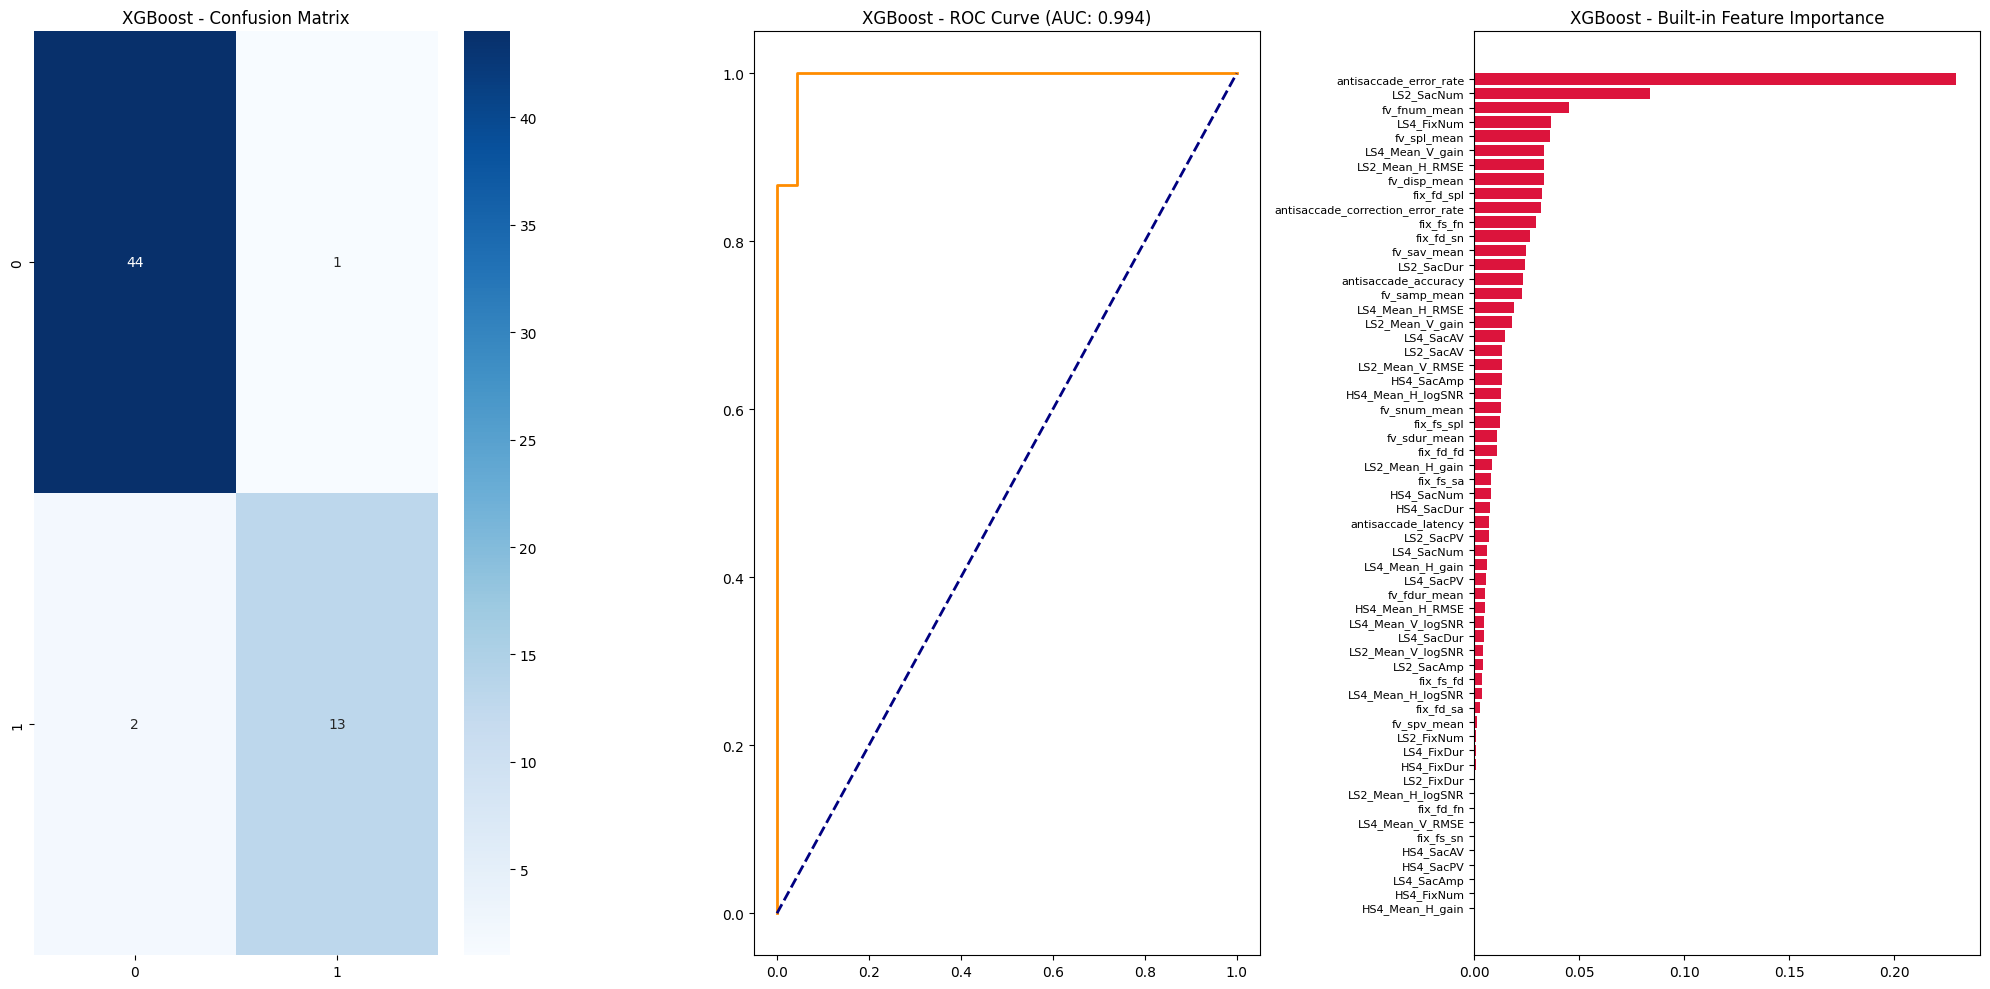

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, roc_curve, confusion_matrix
from xgboost import XGBClassifier

# 1. Load Data
df = pd.read_csv('synthetic_eye_tracking_HC_SZ_300.csv')
X = df.drop(columns=['subject_id', 'label', 'calibration_error'])
y = LabelEncoder().fit_transform(df['label'])
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test, sub_train, sub_test, cal_train, cal_test = train_test_split(
    X, y, df['subject_id'], df['calibration_error'], test_size=0.2, stratify=y, random_state=42
)

# 2. Train Model
# Restricting depth and learning rate to prevent overfitting on small data
model = XGBClassifier(max_depth=3, learning_rate=0.05, n_estimators=200, eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)

# 3. Predict & Save
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# XGBoost recommended save method
model.save_model('xgboost_model.json')

pd.DataFrame({
    'subject_id': sub_test.values, 'actual_label': y_test, 
    'predicted_label': y_pred, 'predicted_prob': y_prob, 'calibration_error': cal_test.values
}).to_csv('predictions_xgboost.csv', index=False)

print(f"XGBoost Results -> Accuracy: {accuracy_score(y_test, y_pred):.4f} | ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

# 4. Plotting
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("XGBoost - Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2)
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title(f"XGBoost - ROC Curve (AUC: {roc_auc_score(y_test, y_prob):.3f})")

# XGBoost Built-in Feature Importance
importances = model.feature_importances_
indices = np.argsort(importances)

axes[2].barh(range(len(indices)), importances[indices], color='crimson')
axes[2].set_yticks(range(len(indices)))
axes[2].set_yticklabels([feature_names[i] for i in indices], fontsize=8)
axes[2].set_title("XGBoost - Built-in Feature Importance")

plt.tight_layout()
plt.show()